In [4]:
!pip install numpy.typing==1.1.1

  Preparing metadata (setup.py) ... done
  Created wheel for numpy.typing: filename=numpy_typing-1.1.1-py3-none-any.whl size=6564 sha256=6c0113f1969408b3a75ff1db2e52b31a3d8bba98f3961facb3ccd22690625253
  Stored in directory: /root/.cache/pip/wheels/0b/9d/a3/ae73b45a6d8bf1d0f4ef6bc897a9d11be82b1b261836c6f156
Successfully built numpy.typing

[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [34]:
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split

#y = pd.read_csv("y_f_correct_scale_noz.csv", index_col=0)
#X = pd.read_csv("X_f_correct_scale_noz.csv", index_col=0)

y = pd.read_csv("AY_DATA.csv", index_col=0, parse_dates=True)
X = pd.read_csv("AX_DATA.csv", index_col=0, parse_dates=True)

X = X.drop("DS", axis=1)
X = X.drop("DPR", axis=1)
#X = X.drop("STR", axis=1)
X = X.drop("MKT", axis=1)
X = X.drop("SPX Index - Volume", axis=1)
#X = X.drop("Jump", axis=1)
X = X.drop("realized_skew", axis=1)
#X = X.drop("realized_kurt", axis=1)

#X = X.drop("RV_month", axis=1)
#X = X.drop("RV_week", axis=1)
#X = X.drop("RV_day", axis=1)

#X = X.drop("VIX", axis=1)
#X = X.drop("VIX_week", axis=1)
#X = X.drop("VIX_month", axis=1)

X = X.drop("vix_term_relative", axis=1)
X = X.drop("VIX_relative_week", axis=1)
X = X.drop("VIX_relative_month", axis=1)

X = X.drop("vix_term_ratio", axis=1)
X = X.drop("VIX_ratio_week", axis=1)
X = X.drop("VIX_ratio_month", axis=1)


In [19]:
X['Jump_Ind'] = (X['Jump'] > X['Jump'].quantile(0.95)).astype(int)
X.drop('Jump', axis=1, inplace=True)

In [4]:
!pip install statsmodels
import statsmodels.api as sm


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [37]:
import numpy as np
import statsmodels.api as sm

def rolling_frame_har(X, y, train_days=441, predict_days=5):
    """
    Rolling HAR framework using NumPy arrays.

    Parameters:
    - X: np.ndarray, shape (n_samples, n_features)
    - y: np.ndarray, shape (n_samples,)
    - train_days: int, number of days to use for training
    - predict_days: int, number of days to predict each round

    Returns:
    - predictions: np.ndarray, shape (n_total_preds,)
    - prediction_indices: np.ndarray
    """

    n = len(y)
    predictions = []
    prediction_indices = []

    start = 0
    while start + train_days < n:
        end_train = start + train_days
        end_test = min(end_train + predict_days, n)  # Allow incomplete final window

        X_train = X[start:end_train]
        y_train = y[start:end_train]
        X_test = X[end_train:end_test]

        if len(X_test) == 0:
            break  # No more test data

        if np.isnan(X_train).any() or np.isnan(y_train).any() or np.isnan(X_test).any():
            print(f"Skipping window at index {start} due to NaNs.")
            start += predict_days
            continue

        X_train_with_constant = sm.add_constant(X_train, has_constant='add')
        har_model = sm.OLS(y_train, X_train_with_constant).fit()

        X_test_with_constant = sm.add_constant(X_test, has_constant='add')
        y_pred = har_model.predict(X_test_with_constant)

        predictions.append(y_pred)
        prediction_indices.append(np.arange(end_train, end_test))

        start += predict_days

    return np.concatenate(predictions), np.concatenate(prediction_indices)


In [55]:
len(X)


2744

In [16]:
X

,VIX,Jump,RV_day,RV_week,RV_month,realized_kurt,VIX_week,VIX_month
Date,,,,,,,,
2014-06-02,11.58,0.000000e+00,0.003872,0.002929,0.004039,5.010462,11.548,12.434545
2014-06-03,11.87,4.752437e-06,0.002720,0.002966,0.003972,3.741934,11.620,12.371818
2014-06-04,12.08,2.688952e-06,0.002779,0.002938,0.003853,7.626955,11.700,12.334091
2014-06-05,11.68,1.651438e-06,0.003762,0.003146,0.003825,3.213550,11.722,12.260909
2014-06-06,10.73,1.616947e-06,0.002433,0.003113,0.003732,5.535330,11.588,12.121364
...,...,...,...,...,...,...,...,...
2018-05-16,13.42,4.501630e-07,0.004115,0.004537,0.006220,3.846088,13.372,15.242727
2018-05-17,13.43,8.502060e-07,0.004447,0.004569,0.006244,3.111884,13.412,15.160000
2018-05-18,13.42,4.307622e-06,0.004540,0.004582,0.006241,4.985708,13.566,15.060909


In [40]:
predictions, prediction_indices = rolling_frame_har(np.array(X), np.array(y), train_days=441, predict_days=5)

In [58]:
len(predictions)

2303

In [43]:
# Convert to correct shape & evaluate
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_percentage_error

# Load your scaler
#scaler = joblib.load('A_y_scaler_lagged_VIX.pkl')


y_true = y.iloc[prediction_indices]  
y_pred = predictions

## Reshape and inverse transform
#y_true = scaler.inverse_transform(np.array(y_true).reshape(-1, 1))
#y_pred = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# Evaluate
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"MAPE: {mape:.6f} ({mape * 100:.2f}%)")

MAPE: 0.264188 (26.42%)


In [28]:
len(y_true)

560

In [46]:
# Convert to correct shape & evaluate
import numpy as np
import joblib
from sklearn.metrics import mean_squared_error

# Load your scaler
#scaler = joblib.load('A_y_scaler_lagged_VIX.pkl')


y_true = y.iloc[prediction_indices]  
y_pred = predictions
# Reshape and inverse transform
#y_true = scaler.inverse_transform(np.array(y_true).reshape(-1, 1))
#y_pred = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

mse = mean_squared_error(y_true, y_pred)

print(f"Mean Squared Error (MSE): {mse:.8f}")

Mean Squared Error (MSE): 0.00000836


In [49]:
def qlike(y_true, y_pred):
    """
    Canonical QLIKE loss: log(pred) + true/pred - log(true) - 1

    Parameters:
    - y_true: true realized variances (must be > 0)
    - y_pred: predicted variances (must be > 0)

    Returns:
    - qlike_loss: scalar average QLIKE loss
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    eps = 1e-8
    y_true = np.clip(y_true, eps, None)
    y_pred = np.clip(y_pred, eps, None)

    return np.mean(np.log(y_pred) + y_true / y_pred - np.log(y_true) - 1)
qlike(y_true, y_pred)

0.2213994737506222

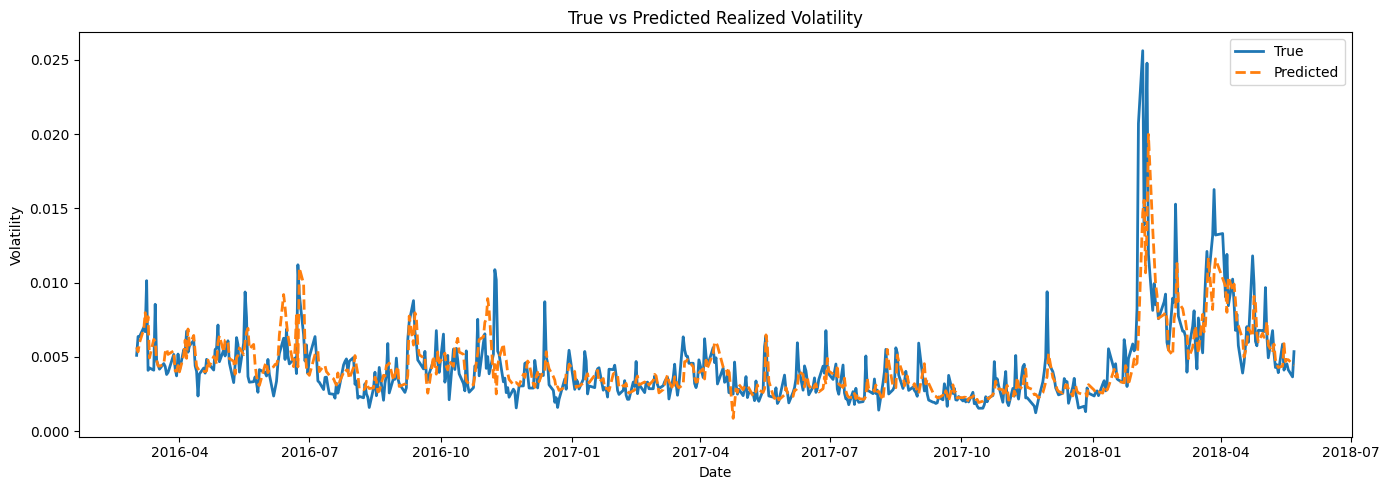

In [52]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Get the prediction dates
prediction_dates = y.index[prediction_indices]

y_pred = predictions
# Step 2: Build a DataFrame for easy plotting
df_plot = pd.DataFrame({
    'Date': prediction_dates,
    'True': np.array(y_true).ravel(),
    'Predicted': np.array(y_pred).ravel()
}).set_index('Date')

# Step 3: Plot
plt.figure(figsize=(14, 5))
plt.plot(df_plot.index, df_plot['True'], label='True', linewidth=2)
plt.plot(df_plot.index, df_plot['Predicted'], label='Predicted', linewidth=2, linestyle='--')
plt.title('True vs Predicted Realized Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error

# naive prediction: next day's vol = today's vol
y_pred = y_true[:-1]
y_true_next = y_true[1:]

print("Naive MAPE:", mean_absolute_percentage_error(y_true_next, y_pred))

Naive MAPE: 0.5824552688159675


In [219]:
np.save("standard_har_preds.npy", y_pred)
np.save("y_true.npy", y_true)

In [117]:
import numpy as np

def qlike(y_true, y_pred):
    """
    Canonical QLIKE loss: log(pred) + true/pred - log(true) - 1

    Parameters:
    - y_true: true realized variances (must be > 0)
    - y_pred: predicted variances (must be > 0)

    Returns:
    - qlike_loss: scalar average QLIKE loss
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    eps = 1e-8
    y_true = np.clip(y_true, eps, None)
    y_pred = np.clip(y_pred, eps, None)

    return np.mean(np.log(y_pred) + y_true / y_pred - np.log(y_true) - 1)
qlike(y_true, y_pred)

0.040646872181482406

In [ ]:
# Flatten arrays for plotting
y_true_is = y_true
#.flatten()
y_hat_is = y_pred

# Get datetime index for predictions
prediction_dates = X.iloc[prediction_indices].index

# Define color map
#cluster_colors = {0: 'xkcd:pinkish', 1: 'pink', 2: 'purple'}

# Ensure cluster label length matches
#test_cluster_labels_all = np.array(test_cluster_labels_all).flatten()
#assert len(test_cluster_labels_all) == len(y_hat_is), "Mismatch in prediction and cluster label lengths"

# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(prediction_dates, y_true, label='Realized Volatility (SPX)', linewidth=2, linestyle='dashed', color='olive')

# Plot predicted volatility with color by cluster
start_idx = 0
for i in range(1, len(y_hat_is)):
    if (test_cluster_labels_all[i] != test_cluster_labels_all[start_idx]) or (i == len(y_hat_is) - 1):
        end_idx = i + 1 if i == len(y_hat_is) - 1 else i
        segment_x = prediction_dates[start_idx:end_idx]
        segment_y = y_hat_is[start_idx:end_idx]
        cluster_id = test_cluster_labels_all[start_idx]
        ax.plot(segment_x, segment_y, color=cluster_colors[cluster_id], linewidth=2,
                label=f'Predicted Cluster {cluster_id}' if start_idx == 0 else "")
        start_idx = i

# Set title and labels
ax.set_title('Predicted vs Realized SPX Volatility')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.grid(True)

# Format x-axis to show selected quarterly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

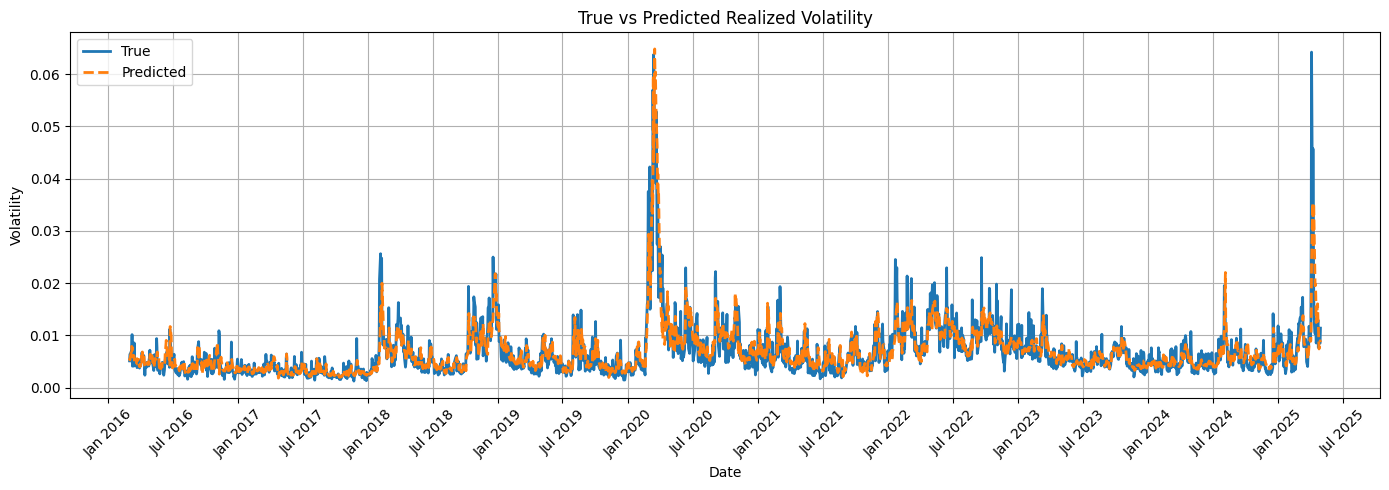

In [58]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# Step 1: Get the prediction dates
prediction_dates = y.index[prediction_indices]

y_pred = predictions

# Step 2: Build a DataFrame for easy plotting
df_plot = pd.DataFrame({
    'Date': prediction_dates,
    'True': np.array(y_true).ravel(),
    'Predicted': np.array(y_pred).ravel()
}).set_index('Date')

# Step 3: Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_plot.index, df_plot['True'], label='True', linewidth=2)
ax.plot(df_plot.index, df_plot['Predicted'], label='Predicted', linewidth=2, linestyle='--')

# ✅ Enforce quarterly ticks

# Format x-axis to show selected quarterly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7], bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Labels and formatting
ax.set_title('True vs Predicted Realized Volatility')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("standard_plot.pdf", format="pdf")
plt.show()




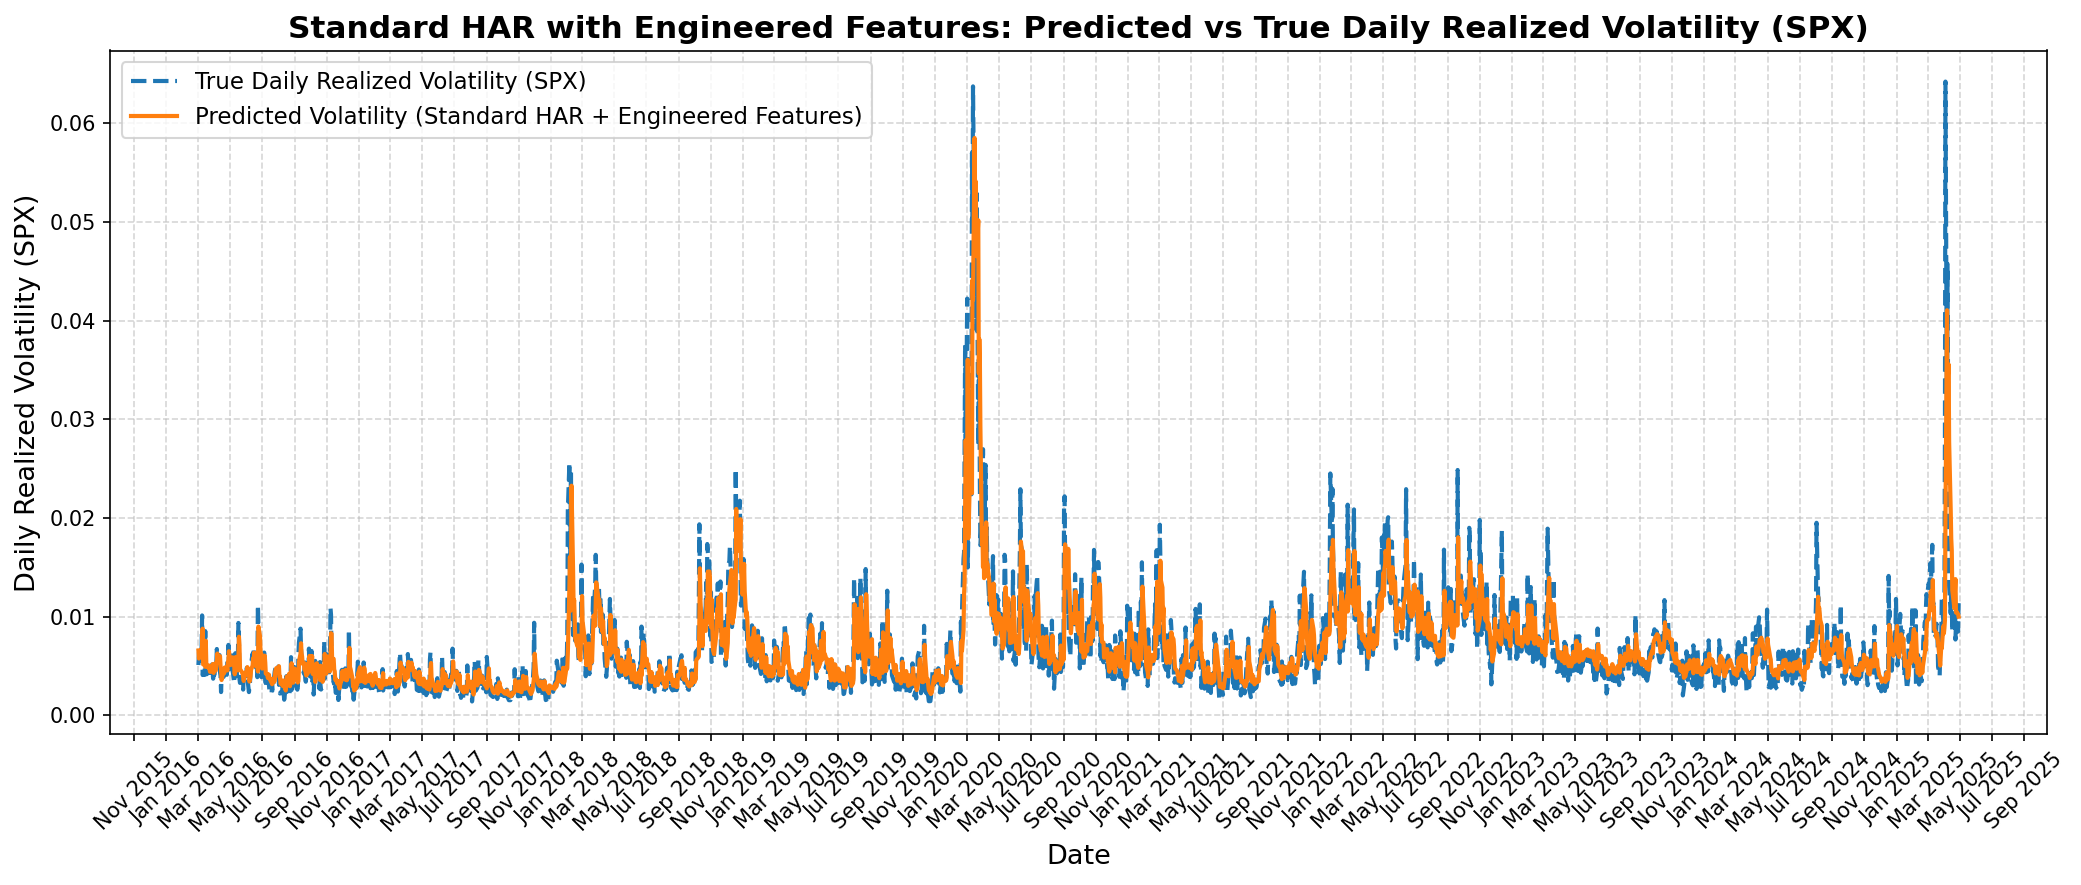

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Flatten arrays

prediction_dates = X.iloc[prediction_indices].index

# Define consistent color for true and predicted lines
true_color = '#1f77b4'   # standard matplotlib blue
pred_color = '#ff7f0e'   # standard matplotlib orange

# Create plot
fig, ax = plt.subplots(figsize=(14, 6), dpi=150)

# Plot true volatility
line_true, = ax.plot(prediction_dates, y_true,
                     label='True Daily Realized Volatility (SPX)',
                     linewidth=2, linestyle='--', color=true_color)

# Plot predicted volatility (no clustering, so one line)
line_pred, = ax.plot(prediction_dates, y_pred,
                     label='Predicted Volatility (Standard HAR + Engineered Features)',
                     linewidth=2, color=pred_color)

# Axes titles and styling
ax.set_title('Standard HAR with Engineered Features: Predicted vs True Daily Realized Volatility (SPX)',
             fontsize=15, weight='bold')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Daily Realized Volatility (SPX)', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)

# Quarterly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 3, 5, 7, 9, 11], bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Legend
ax.legend([line_true, line_pred], [line_true.get_label(), line_pred.get_label()],
          fontsize=11, loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('Standard_HAR_features.pdf')

plt.show()


In [52]:
print(len(y_true))

560


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c491ba08-7b0b-4e77-bbce-46de4cee5dd0' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>